# BioJEPA v0.6 Training Pipeline

In [1]:
import torch
import random
import gc
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

from biojepa_v0_6 import BioJepa, BioJepaConfig
from dataloader_v0_6 import PretrainLoader, AlignmentLoader, TrainingLoader
from training_v0_6 import create_model, load_feature_banks, run_pretraining, run_alignment, run_full_training, train_linear_decoder, maybe_compile
from config_v0_6 import PretrainConfig, AlignmentConfig, FullTrainingConfig, DecoderConfig, DataConfig
from evals.evals import EvalContext, run_pretraining_evals, run_alignment_evals, run_full_model_evals, save_report

## Device & Paths

In [2]:
def get_device():
    device = 'cpu'
    if torch.cuda.is_available():
        torch.cuda.manual_seed(1337)
        device = 'cuda'
    print(f'using {device}')
    return torch.device(device)

torch.manual_seed(1337)
random.seed(1337)
torch.set_float32_matmul_precision('high')

device = get_device()

USE_AMP = torch.cuda.is_available()
USE_COMPILE = torch.cuda.is_available()
USE_FUSED = torch.cuda.is_available()

data_root = Path('/home/ubuntu/data/v0_6')
ref_root = Path('/home/ubuntu/data/reference_data')

data_cfg = DataConfig(
    data_root=data_root,
    checkpoint_dir=data_root / 'checkpoints',
    ref_dir = ref_root,
    eval_results_dir=data_root / 'eval_results'
)

using cuda


## Hyperparameters

In [3]:
# Model architecture
model_cfg = BioJepaConfig(
    num_genes=10000,
    n_layer=2,
    heads=2,
    embed_dim=8,
    mlp_ratio=4.0,
    n_pre_layer=2,
    mask_ratio=0.6,
    gaussian_scale=2.0,
    film_linear_multiple=1.0,
    sim_coeff=25.0,
    std_coeff=25.0,
    cov_coeff=1.0,
    pert_latent_dim= 8,#320,
    pert_mode_dim= 8, #64
)

# Training configs
pt_cfg = PretrainConfig(epochs=1, lr=1e-3, batch_size=128) #n_steps=1000,,
align_cfg = AlignmentConfig(epochs=100, lr=4e-3, batch_size=32)
full_cfg = FullTrainingConfig(epochs=1, predictor_lr=1e-3, batch_size=128) # epochs=1,
decoder_cfg = DecoderConfig(epochs=1, lr=1e-3, batch_size=128) # epochs=1,

## Initialize Model & Data

In [4]:
model = create_model(model_cfg, device)
model = maybe_compile(model, USE_COMPILE)
seq_banks, target_bank = load_feature_banks(data_cfg, device)

print(f'Student/Teacher: {sum(p.numel() for p in model.student.parameters() if p.requires_grad):,}')
print(f'ACpredictor: {sum(p.numel() for p in model.predictor.parameters() if p.requires_grad):,}')
print(f'PerturbationComposer: {sum(p.numel() for p in model.composer.parameters() if p.requires_grad):,}')

Loaded DNA embeddings: torch.Size([11643, 1536])
Loaded chemical embeddings: torch.Size([188, 1536])
Loaded target embeddings: torch.Size([9975, 320])
Student/Teacher: 84,074
ACpredictor: 84,864
PerturbationComposer: 26,152


### Load pretraining model from checkpoint (for resuming)

In [5]:
# checkpoint_path = data_cfg.checkpoint_dir / 'biojepa_v0_6_pt_final.pt'
# with torch.serialization.safe_globals([BioJepaConfig]):
#     checkpoint = torch.load(checkpoint_path)

# keys = model.load_state_dict(checkpoint['model'])
# keys

<All keys matched successfully>

## Function to decompress and recompress a directory

In [6]:
def decompress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'decompress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez(tmp_path, **arrays)
        tmp_path.replace(src_path)

def compress_npz(root_dir):
    root_dir = Path(root_dir)
    for src_path in root_dir.rglob('*.npz'):
        print(f'compress {src_path}')
        with np.load(src_path, allow_pickle=False) as data:
            arrays = {k: data[k] for k in data.files}
        tmp_path = src_path.with_suffix('.tmp.npz')
        np.savez_compressed(tmp_path, **arrays)
        tmp_path.replace(src_path)

## Pretraining

In [7]:
# decompress_npz(data_cfg.data_root / 'pretraining')

In [8]:
pt_train_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pretraining', 
    device=device )
pt_val_loader = PretrainLoader(
    batch_size=pt_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pretraining', 
    device=device)

found 1123 shards for split train
found 71 shards for split val


In [9]:
pt_results = run_pretraining(model, pt_train_loader, pt_val_loader, pt_cfg, device, data_cfg.checkpoint_dir, model_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Pretraining: 2874880 samples, 22460 steps/epoch, 22460 total steps
Step 0 | val loss: 69.3079
Step 0 | Loss: 68.94910 | LR: 4.00e-05
Step 25 | Loss: 68.64476 | LR: 4.13e-05
Step 50 | Loss: 67.63364 | LR: 4.49e-05
Step 75 | Loss: 67.23290 | LR: 5.08e-05
Step 100 | val loss: 66.1685
Step 100 | Loss: 66.27591 | LR: 5.91e-05
Step 125 | Loss: 65.13144 | LR: 6.96e-05
Step 150 | Loss: 63.26105 | LR: 8.23e-05
Step 175 | Loss: 62.30927 | LR: 9.71e-05
Step 200 | val loss: 60.4329
Step 200 | Loss: 60.65006 | LR: 1.14e-04
Step 225 | Loss: 58.56940 | LR: 1.33e-04
Step 250 | Loss: 55.73676 | LR: 1.54e-04
Step 275 | Loss: 53.75332 | LR: 1.76e-04
Step 300 | val loss: 52.2821
Step 300 | Loss: 52.30937 | LR: 2.01e-04
Step 325 | Loss: 51.42742 | LR: 2.26e-04
Step 350 | Loss: 50.36556 | LR: 2.54e-04
Step 375 | Loss: 49.25151 | LR: 2.82e-04
Step 400 | val loss: 49.0584
Step 400 | Loss: 49.06623 | LR: 3.12e-04
Step 425 | Loss: 47.95517 | LR: 3.43e-04
Step 450 | Loss: 45.83294 | LR: 3.74e-04
Step 475 | Loss:

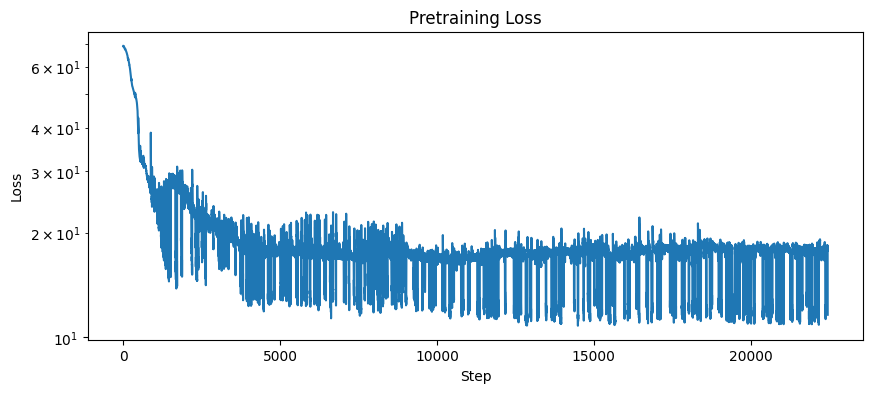

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(pt_results['loss_history'])
plt.yscale('log')
plt.title('Pretraining Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Pretraining Evals

In [11]:
eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim, 
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': pt_cfg.batch_size
})
pt_eval_results = run_pretraining_evals(eval_ctx)

save_report(pt_eval_results, data_cfg.eval_results_dir / 'pretraining_eval_report.json')
pt_eval_results

Using cuda
found 121 shards for split test


batch_invariance: Extracting embeddings: 100%|████████████████████████████████| 303/303 [00:08<00:00, 37.05it/s]


Training batch classifier...
Training perturbation classifier...
batch_invariance: Batch=0.0122 (3.3x), Pert=0.0366 (39.1x)
Loading KEGG_2021_Human...
  320 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
gene_embedding_pathways: KEGG sil=-0.2286, Reactome sil=-0.2079
found 121 shards for split test


cell_type_probing: Extracting embeddings: 100%|███████████████████████████████| 303/303 [00:03<00:00, 82.99it/s]


Training cell type classifier...
cell_type_probing: Accuracy=0.9170 (1.8x chance), Macro F1=0.8426
found 121 shards for split test


...

embedding_consistency: Extracting embeddings: 100%|███████████████████████████| 303/303 [00:03<00:00, 85.18it/s]


embedding_consistency: Intra=2.6646, Inter=2.1875, Ratio=0.82x
found 121 shards for split test


latent_space_health: Extracting embeddings: 100%|█████████████████████████████| 303/303 [00:03<00:00, 83.21it/s]

latent_space_health: Eff_dim_90=4/8, Mean_var=0.6304, Isotropy=0.000111
Saved report to /home/ubuntu/data/v0_6/eval_results/pretraining_eval_report.json


{'batch_invariance': {'config': {'samples': 38784,
   'embedding_dim': 8,
   'num_batches': 267,
   'num_perturbations': 1068},
  'batch_classifier': {'accuracy': 0.012247002707232177,
   'chance': 0.003745318352059925,
   'above_chance_ratio': 3.2699497228309915},
  'perturbation_classifier': {'accuracy': 0.03661209230372567,
   'chance': 0.0009363295880149813,
   'above_chance_ratio': 39.10171458037901},
  'invariance_ratio': 2.9894736842105263},
 'gene_embedding_pathways': {'config': {'n_genes': 10000},
  'kegg': {'silhouette_score': -0.2285897135734558,
   'knn_accuracy': 0.01932304411422947,
   'knn_std': 0.00670425268449904,
   'n_classes': 122,
   'n_samples': 3312},
  'reactome': {'silhouette_score': -0.2079334855079651,
   'knn_accuracy': 0.019720749024807364,
   'knn_std': 0.0048056339242478294,
   'n_classes': 167,
   'n_samples': 4564}},
 'essential_gene_prediction': {'error': 'DepMap file not found: /home/ubuntu/reference_data/depmap/CRISPRGeneEffect.csv'},
 'cell_type_pro

In [12]:
# compress_npz(data_cfg.data_root / 'pretraining')

In [13]:
del pt_train_loader, pt_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 2: Perturbation Alignment

In [6]:
align_train_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device, total_samples=1250)
align_val_loader = AlignmentLoader(
    batch_size=align_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'pert_embd', 
    device=device)

found 1 shards for split train
found 1 shards for split val


In [7]:
align_results = run_alignment(model, align_train_loader, align_val_loader, seq_banks, target_bank, align_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

Alignment: 1250 samples, 39 steps/epoch, 3900 total steps
Step 0 | val loss: 3.9855
Step 0 | Loss: 4.01025 | LR: 1.60e-04
Step 100 | Loss: 3.25854 | LR: 2.20e-03
Step 200 | Loss: 3.31251 | LR: 4.00e-03
Step 300 | Loss: 3.22278 | LR: 3.99e-03
Step 400 | Loss: 3.46240 | LR: 3.97e-03
Step 500 | val loss: 2.8691
Step 500 | Loss: 3.22644 | LR: 3.93e-03
Step 600 | Loss: 3.02140 | LR: 3.88e-03
Step 700 | Loss: 3.25001 | LR: 3.82e-03
Step 800 | Loss: 3.43018 | LR: 3.74e-03
Step 900 | Loss: 3.46436 | LR: 3.65e-03
Step 1000 | val loss: 2.8787
Step 1000 | Loss: 3.20300 | LR: 3.55e-03
Step 1100 | Loss: 3.28711 | LR: 3.44e-03
Step 1200 | Loss: 3.06420 | LR: 3.31e-03
Step 1300 | Loss: 3.41260 | LR: 3.18e-03
Step 1400 | Loss: 3.45459 | LR: 3.04e-03
Step 1500 | val loss: 2.8804
Step 1500 | Loss: 3.26807 | LR: 2.89e-03
Step 1600 | Loss: 3.28516 | LR: 2.74e-03
Step 1700 | Loss: 3.43555 | LR: 2.58e-03
Step 1800 | Loss: 3.31642 | LR: 2.41e-03
Step 1900 | Loss: 3.33887 | LR: 2.25e-03
Step 2000 | val loss: 

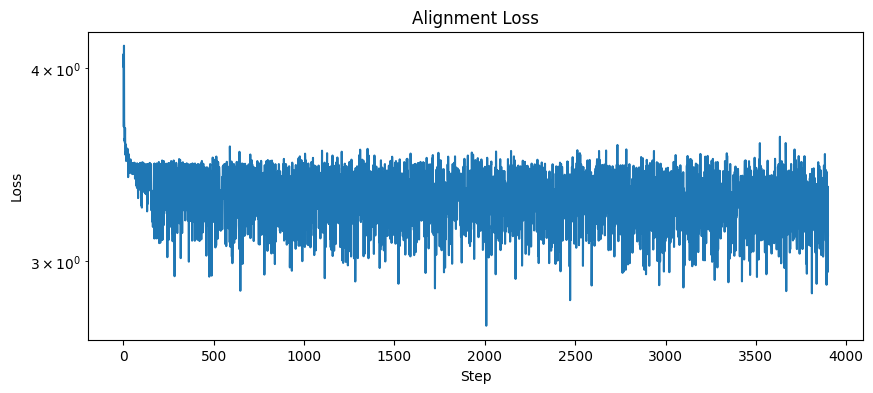

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(align_results['loss_history'])
plt.yscale('log')
plt.title('Alignment Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### Alignment Evals

In [9]:
align_eval_ctx = EvalContext.from_trained_model(model, decoder=None, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': align_cfg.batch_size
})
align_eval_results = run_alignment_evals(align_eval_ctx)

save_report(align_eval_results, data_cfg.eval_results_dir / 'alignment_eval_report.json')
align_eval_results

Using cuda
Loaded 10797 v0.6 alignment pairs
Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Encoded DNA sequences: torch.Size([11643, 8])
Encoded chemical sequences: torch.Size([188, 8])
Loaded target bank: torch.Size([9975, 320])
Encoded protein targets: torch.Size([9975, 8])
seq_to_target_retrieval: dna_mrr=0.0016
cross_modality_target_consistency: Within=0.9533, Between=0.9428, Ratio=1.01x
seq_target_gap_analysis: dna_gap=3.37
paired_alignment_quality: dna_sim=0.3628
mode_sensitivity: Classification_acc=0.1786 (1.2x chance)
fusion_quality: Fused_var=4.6556, Seq_var=4.4904, Target_var=0.0281
missing_data_robustness: Fused_MRR=0.0060, Seq_only=0.0058, Target_only=0.9975
found 121 shards for split test


multi_pert_alignment: Scanning for multi-pert: 100%|█████████████████████████| 500/500 [00:01<00:00, 250.11it/s]


Loaded 27264 HGNC gene family annotations
target_family_probing: seq_only=0.0248, target_only=0.0714, fused=0.0303
Saved report to /home/ubuntu/data/v0_6/eval_results/alignment_eval_report.json


{'seq_to_target_retrieval': {'config': {'n_targets': 9975},
  'by_modality': {'dna': {'mrr': 0.001637272014356731,
    'median_rank': 4023.0,
    'mean_rank': 4304.8236290095,
    'n_queries': 10631,
    'n_targets': 9975,
    'recall_at_k': {'1': 0.00018812905653278148,
     '5': 0.0012228388674630796,
     '10': 0.0022575486783933778,
     '20': 0.004326968300253974,
     '50': 0.008653936600507948}}}},
 'cross_modality_target_consistency': {'config': {'n_valid_targets': 915,
   'n_within_pairs': 1452,
   'n_between_pairs': 5000},
  'metrics': {'within_target_sim': 0.953281044960022,
   'between_target_sim': 0.9428001397073269,
   'consistency_ratio': 1.0111167837288915}},
 'seq_target_gap_analysis': {'target_variance': 0.22719137370586395,
  'n_targets': 9975,
  'dna': {'seq_variance': 40.21430969238281,
   'centroid_distance': 25.117700576782227,
   'mean_within_seq': 7.602833522476483,
   'mean_seq_to_target': 25.607276916503906,
   'gap_ratio': 3.368122798006868,
   'n_sequences'

In [10]:
del align_train_loader, align_val_loader, align_eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Stage 3: Full Training

In [11]:
train_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device)
val_loader = TrainingLoader(
    batch_size=full_cfg.batch_size, 
    split='val', data_dir=data_cfg.data_root / 'training', 
    device=device)

full_results = run_full_training(model, train_loader, val_loader, seq_banks, target_bank, full_cfg, device, data_cfg.checkpoint_dir, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 976 shards for split train
found 62 shards for split val
Full training: 2498560 samples, 19520 steps/epoch, 19520 total steps
Step 0 | val loss: 68.3483
Step 0 | Loss: 55.70014 | LR: 4.00e-05
Step 25 | Loss: 53.47448 | LR: 4.17e-05
Step 50 | Loss: 53.62706 | LR: 4.65e-05
Step 75 | Loss: 50.51499 | LR: 5.43e-05
Step 100 | val loss: 50.7299
Step 100 | Loss: 49.41124 | LR: 6.52e-05
Step 125 | Loss: 45.34379 | LR: 7.90e-05
Step 150 | Loss: 62.59064 | LR: 9.57e-05
Step 175 | Loss: 51.11631 | LR: 1.15e-04
Step 200 | val loss: 46.7535
Step 200 | Loss: 46.49851 | LR: 1.37e-04
Step 225 | Loss: 48.54788 | LR: 1.62e-04
Step 250 | Loss: 41.90724 | LR: 1.89e-04
Step 275 | Loss: 38.79902 | LR: 2.18e-04
Step 300 | val loss: 39.4293
Step 300 | Loss: 39.26818 | LR: 2.49e-04
Step 325 | Loss: 35.96304 | LR: 2.81e-04
Step 350 | Loss: 34.26025 | LR: 3.16e-04
Step 375 | Loss: 37.99441 | LR: 3.51e-04
Step 400 | val loss: 33.0517
Step 400 | Loss: 37.43595 | LR: 3.88e-04
Step 425 | Loss: 34.63375 | LR: 4

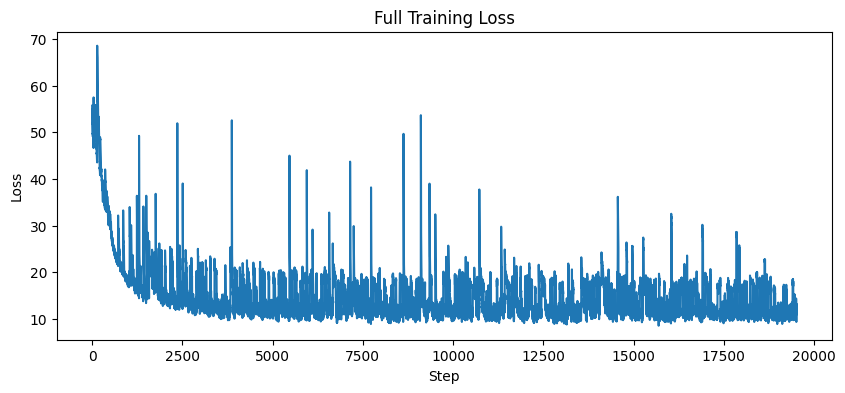

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(full_results['loss_history'])
plt.title('Full Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [13]:
del train_loader, val_loader
gc.collect()
torch.cuda.empty_cache()

## Linear Decoder Training

In [14]:
decoder_train_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size, 
    split='train', data_dir=data_cfg.data_root / 'training', 
    device=device, 
    total_samples=101682)
decoder_val_loader = TrainingLoader(
    batch_size=decoder_cfg.batch_size,
    split='val', data_dir=data_cfg.data_root / 'training',
    device=device,
    total_samples=11044)

decoder, decoder_results = train_linear_decoder(model, decoder_train_loader, decoder_val_loader, seq_banks, target_bank, model_cfg, device, data_cfg.checkpoint_dir, decoder_cfg, use_amp=USE_AMP, use_fused_optimizer=USE_FUSED)

found 976 shards for split train
found 62 shards for split val
Decoder Step 0 | val loss: 0.6477
Decoder Step 0 | Loss: 0.66398
Decoder Step 25 | Loss: 0.61865
Decoder Step 50 | Loss: 1.35761
Decoder Step 75 | Loss: 1.07856
Decoder Step 100 | val loss: 0.6427
Decoder Step 100 | Loss: 0.38782
Decoder Step 125 | Loss: 0.35139
Decoder Step 150 | Loss: 0.32486
Decoder Step 175 | Loss: 0.29296
Decoder Step 200 | val loss: 0.5029
Decoder Step 200 | Loss: 0.26014
Decoder Step 225 | Loss: 0.81111
Decoder Step 250 | Loss: 0.23915
Decoder Step 275 | Loss: 0.22590
Decoder Step 300 | val loss: 0.6090
Decoder Step 300 | Loss: 0.24411
Decoder Step 325 | Loss: 0.68206
Decoder Step 350 | Loss: 0.20887
Decoder Step 375 | Loss: 0.63168
Decoder Step 400 | val loss: 0.2855
Decoder Step 400 | Loss: 0.20376
Decoder Step 425 | Loss: 0.60364
Decoder Step 450 | Loss: 0.24215
Decoder Step 475 | Loss: 0.56569
Decoder Step 500 | val loss: 0.4231
Decoder Step 500 | Loss: 0.19370
Decoder Step 525 | Loss: 0.23179
De

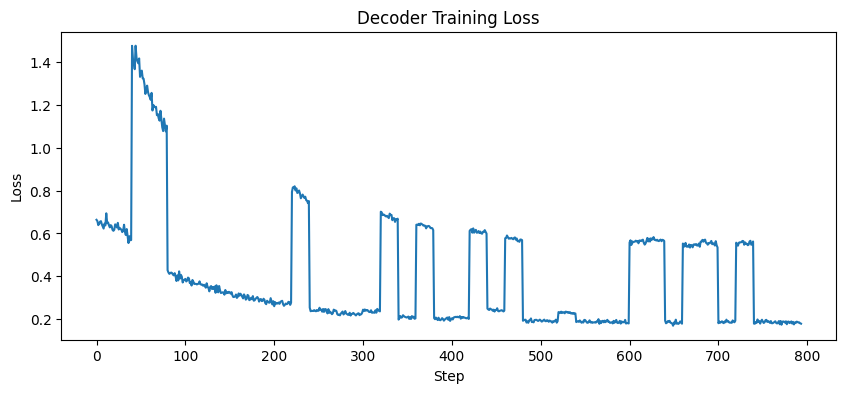

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(decoder_results['loss_history'])
plt.title('Decoder Training Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Full Model Evals

In [16]:
eval_ctx = EvalContext.from_trained_model(model, decoder=decoder, data_root=data_cfg.data_root, ref_dir=data_cfg.ref_dir, config={
    'num_genes': model_cfg.num_genes, 'embed_dim': model_cfg.embed_dim,
    'n_layer': model_cfg.n_layer, 'heads': model_cfg.heads, 'batch_size': full_cfg.batch_size
})
full_eval_results = run_full_model_evals(eval_ctx)

save_report(full_eval_results, data_cfg.eval_results_dir / 'full_model_eval_report.json')
full_eval_results

Using cuda
found 121 shards for split test


Running test inference:   0%|                                                           | 0/303 [00:00<?, ?it/s]

Loaded DNA seq bank: torch.Size([11643, 1536])
Loaded chemical seq bank: torch.Size([188, 1536])
Loaded target bank: torch.Size([9975, 320])


Running test inference:  27%|█████████████▋                                    | 83/303 [00:10<00:16, 12.98it/s]/home/ubuntu/code/biojepa/evals/evals.py:395: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(p_top, t_top)
Running test inference:  62%|██████████████████████████████▏                  | 187/303 [00:26<00:07, 15.14it/s]/home/ubuntu/code/biojepa/evals/evals.py:395: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(p_top, t_top)
Running test inference: 100%|█████████████████████████████████████████████████| 303/303 [00:34<00:00,  8.71it/s]


Aggregated 1083 perturbations, 38782 samples
expression_prediction: MSE=0.2704, R2_all=0.8524
gene_level_analysis: Dir_acc=0.8745, Top50_acc=0.2093


perturbation_retrieval (dna): 100%|███████████████████████████████████████████| 100/100 [03:27<00:00,  2.07s/it]


perturbation_retrieval (dna): MRR=0.0007


perturbation_retrieval (chemical): 100%|████████████████████████████████████████| 13/13 [00:00<00:00, 31.28it/s]


perturbation_retrieval (chemical): MRR=0.0250
uncertainty_calibration: ECE=0.1512, Monotonicity=66.67%
Loading KEGG_2021_Human...
  320 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded
Encoded DNA sequences: torch.Size([11643, 8])
Encoded chemical sequences: torch.Size([188, 8])
Encoded protein targets: torch.Size([9975, 8])
action_vector_pathways DNA: sil=-0.3706042170524597
Loaded 10797 v0.6 alignment pairs
moa_matching: Within=0.7918, Between=0.6269, Ratio=1.263x
Saved report to /home/ubuntu/data/v0_6/eval_results/full_model_eval_report.json


{'expression_prediction': {'config': {'test_perturbations': 1083,
   'genes': 10000,
   'test_samples': 38782},
  'sample_level': {'mse': 0.270391047000885,
   'pearson_r_top20': 0.634027021091793},
  'perturbation_level': {'r2_all_genes': {'mean': 0.8524032627556573,
    'median': 0.8943600654602051},
   'r2_top50_degs': {'mean': 0.20866297073971862, 'median': 0.347967267036438},
   'mse': {'mean': 0.030124498531222343, 'median': 0.02411908656358719}},
  'severity': {'pearson_r': 0.352713406085968,
   'spearman_r': 0.19135601095336402},
  'error_by_magnitude': {'0-0.25': {'mae': 0.1220586970448494,
    'count': 10262109},
   '0.25-0.5': {'mae': 0.2529066205024719, 'count': 492169},
   '0.5-1.0': {'mae': 0.47500959038734436, 'count': 66091},
   '1.0-1.5': {'mae': 0.8850188255310059, 'count': 8398},
   '1.5-2.0': {'mae': 1.3760416507720947, 'count': 1054},
   '2.0+': {'mae': 1.931003451347351, 'count': 179}}},
 'gene_level_analysis': {'config': {'test_perturbations': 1083,
   'genes': 1

In [17]:
del decoder_train_loader, decoder_val_loader, eval_ctx
gc.collect()
torch.cuda.empty_cache()

## Summary

In [ ]:
print('=== Training Complete ===')
print(f'Pretraining final loss: {pt_results["final_loss"]:.5f}')
print(f'Alignment final loss: {align_results["final_loss"]:.5f}')
print(f'Full training final loss: {full_results["final_loss"]:.5f}')
print(f'Decoder final loss: {decoder_results["final_loss"]:.5f}')
print(f'\nCheckpoints saved to: {data_cfg.checkpoint_dir}')
print(f'Eval reports saved to: {data_cfg.eval_results_dir}')